# **custom calss for arcface model that we used to do in the fineturning**

In [2]:
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class ArcFaceLayer(tf.keras.layers.Layer):

    def __init__(self, num_classes, s=64.0, m=0.5, **kwargs):

        super().__init__(**kwargs)

        self.num_classes = num_classes
        self.s = s
        self.m = m

    def build(self, input_shape):

        emb_dim = input_shape[0][-1]

        self.W = self.add_weight(
            name="weights",
            shape=(emb_dim, self.num_classes),
            initializer="glorot_uniform",
            trainable=True
        )

    def call(self, inputs):

        embeddings, labels = inputs

        embeddings = tf.nn.l2_normalize(
            embeddings,
            axis=1
        )

        W = tf.nn.l2_normalize(
            self.W,
            axis=0
        )

        logits = tf.matmul(
            embeddings,
            W
        )

        return logits * self.s

    def get_config(self):

        config = super().get_config()

        config.update({
            "num_classes": self.num_classes,
            "s": self.s,
            "m": self.m
        })

        return config

# **Load the model**

In [3]:
import tensorflow as tf
import json

MODEL_PATH = "C:\\Users\\User\\Downloads\\face_demo\\model\\arcface_finetuned.keras"
CLASS_PATH = "C:\\Users\\User\\Downloads\\face_demo\\model\\class_names.json"

model = tf.keras.models.load_model(

    MODEL_PATH,

    compile=False,

    custom_objects={

        "ArcFaceLayer":
        ArcFaceLayer

    }

)

print(
    "Model loaded"
)

with open(CLASS_PATH,"r") as f:

    CLASS_NAMES = json.load(f)

NUM_CLASSES = len(CLASS_NAMES)

print(
    NUM_CLASSES
)


Model loaded
32


## **do the preprocessing**
uses the same preprocessing + recover_true_cosine() flow as what image was put to fine-turning. It aligns and crops from the live frame, normalizes, runs the model, then displays the prediction + cosine score.


In [4]:
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from mtcnn import MTCNN
import math

# ── FACE ALIGN + PREPROCESS ───────────────────────────────────────
def align_and_crop_face(image_path, target_size=(112,112)):

    img_bgr = cv2.imread(image_path)

    if img_bgr is None:
        raise FileNotFoundError(image_path)

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    results = detector.detect_faces(img_rgb)

    if not results:

        aligned = cv2.resize(img_rgb, target_size)

    else:

        r = max(results, key=lambda x:x['confidence'])

        kp = r['keypoints']

        le = np.array(kp['left_eye'])
        re = np.array(kp['right_eye'])

        dy = re[1] - le[1]
        dx = re[0] - le[0]

        angle = np.degrees(np.arctan2(dy, dx))

        center = ((le[0]+re[0])/2, (le[1]+re[1])/2)

        M = cv2.getRotationMatrix2D(center, angle, 1.0)

        h, w = img_rgb.shape[:2]

        rotated = cv2.warpAffine(img_rgb, M, (w,h))

        x, y, bw, bh = r['box']

        margin = int(max(bw,bh)*0.10)

        x1 = max(0, x-margin)
        y1 = max(0, y-margin)

        x2 = min(w, x+bw+margin)
        y2 = min(h, y+bh+margin)

        face = rotated[y1:y2, x1:x2]

        aligned = cv2.resize(
            face if face.size > 0 else img_rgb,
            target_size
        )

    img_norm = (aligned.astype(np.float32)-127.5)/128.0

    return img_norm, aligned


# ── RECOVER REAL COSINE ───────────────────────────────────────────
def recover_true_cosine(logit, scale=64.0, margin=0.5):

    penalized = np.clip(logit/scale, -1.0, 1.0)

    theta_margin = math.acos(penalized)

    theta = max(0.0, theta_margin-margin)

    return math.cos(theta)


# ── OPEN SET INFERENCE ────────────────────────────────────────────
def run_open_set_inference(
    image_path,
    trained_model,
    classes,
    total_classes,
    threshold=0.65
):

    img_norm, img_display = align_and_crop_face(image_path)

    img_batch = np.expand_dims(img_norm, axis=0)

    dummy_labels = np.zeros((1,total_classes), dtype=np.float32)

    logits = trained_model(
        {
            'input_image':img_batch,
            'input_labels':dummy_labels
        },
        training=False
    )

    true_cosines = np.array(
        [recover_true_cosine(v) for v in logits.numpy()[0]]
    )

    pred_idx = np.argmax(true_cosines)

    highest_similarity = float(true_cosines[pred_idx])

    if highest_similarity >= threshold:

        pred_name = classes[pred_idx]

        is_known = True

    else:

        pred_name = "UNKNOWN STRANGER"

        is_known = False

    return pred_name, highest_similarity, is_known, img_display

# **image manually test**

Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\User\Downloads\face_demo\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\User\Downloads\face_demo\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.
Exception ignored in: <_io.BufferedReader>
Traceback (most recent call last):
  File "c:\Users\User\Downloads\face_demo\venv\Lib\site-packages\lz4\frame\__init__.py", line 753, in flush
    self._fp.flush()
ValueError: I/O operation on closed file.


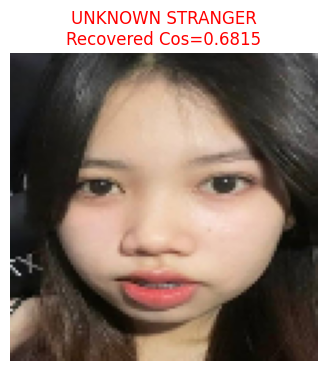

Target Processed    : C:\Users\User\Downloads\face_demo\test_image\ttt1.jpg
System Label Result : UNKNOWN STRANGER
Recovered Cosine    : 0.6815
🚨 Access Denied!


In [6]:
TEST_IMAGE_PATH = "C:\\Users\\User\\Downloads\\face_demo\\test_image\\ttt1.jpg"

OPENS_THRESHOLD = 0.75
detector = MTCNN()
pred_name, sim_score, is_auth, display_img = run_open_set_inference(
    image_path=TEST_IMAGE_PATH,
    trained_model=model,
    classes=CLASS_NAMES,
    total_classes=NUM_CLASSES,
    threshold=OPENS_THRESHOLD
)
plt.figure(figsize=(4,4))

plt.imshow(display_img)

color = 'green' if is_auth else 'red'

plt.title(
    f'{pred_name}\nRecovered Cos={sim_score:.4f}',
    color=color
)

plt.axis('off')

plt.show()


print(
    f"Target Processed    : {TEST_IMAGE_PATH}"
)

print(
    f"System Label Result : {pred_name}"
)

print(
    f"Recovered Cosine    : {sim_score:.4f}"
)

if not is_auth:

    print(
        "🚨 Access Denied!"
    )

# **Webcame test:**

In [8]:
import cv2
import numpy as np
import math

# Reuse existing detector, model, CLASS_NAMES, NUM_CLASSES, OPENS_THRESHOLD

def align_and_crop_face_from_frame(frame_bgr, target_size=(112, 112)):
    img_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    results = detector.detect_faces(img_rgb)

    if not results:
        aligned = cv2.resize(img_rgb, target_size)
        return aligned

    r = max(results, key=lambda x: x["confidence"])
    kp = r["keypoints"]
    le = np.array(kp["left_eye"])
    re = np.array(kp["right_eye"])
    dy = re[1] - le[1]
    dx = re[0] - le[0]
    angle = np.degrees(np.arctan2(dy, dx))
    center = ((le[0] + re[0]) / 2, (le[1] + re[1]) / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    h, w = img_rgb.shape[:2]
    rotated = cv2.warpAffine(img_rgb, M, (w, h))
    x, y, bw, bh = r["box"]
    margin = int(max(bw, bh) * 0.10)
    x1 = max(0, x - margin)
    y1 = max(0, y - margin)
    x2 = min(w, x + bw + margin)
    y2 = min(h, y + bh + margin)
    face = rotated[y1:y2, x1:x2]

    if face.size == 0:
        aligned = cv2.resize(img_rgb, target_size)
    else:
        aligned = cv2.resize(face, target_size)

    return aligned

def preprocess_face(aligned_rgb):
    img_norm = (aligned_rgb.astype(np.float32) - 127.5) / 128.0
    return img_norm

cap = cv2.VideoCapture(0)
dummy_labels = np.zeros((1, NUM_CLASSES), dtype=np.float32)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    aligned_rgb = align_and_crop_face_from_frame(frame)
    img_norm = preprocess_face(aligned_rgb)
    img_batch = np.expand_dims(img_norm, axis=0)

    logits = model(
        {
            "input_image": img_batch,
            "input_labels": dummy_labels,
        },
        training=False,
    )

    true_cosines = np.array([
        recover_true_cosine(v)
        for v in logits.numpy()[0]
    ])
    pred_idx = int(np.argmax(true_cosines))
    highest_similarity = float(true_cosines[pred_idx])

    if highest_similarity >= OPENS_THRESHOLD:
        pred_name = CLASS_NAMES[pred_idx]
        color = (0, 200, 0)
    else:
        pred_name = "UNKNOWN STRANGER"
        color = (0, 0, 255)

    label = f"{pred_name} | Cos={highest_similarity:.4f}"
    cv2.putText(
        frame,
        label,
        (10, 30),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.7,
        color,
        2,
        cv2.LINE_AA,
    )

    cv2.imshow("ArcFace", frame)

    if cv2.waitKey(1) == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()